# <!-- TITLE --> Analysis of the VAE's latent space of MNIST dataset
<!-- DESC --> Visualization and analysis of the VAE's latent space of the dataset MNIST

## Objectives :
 - First data generation from **latent space** 
 - Understanding of underlying principles
 - Model management

Here, we don't consume data anymore, but we generate them ! ;-)

## What we're going to do :

 - Load a saved model
 - Reconstruct some images
 - Latent space visualization
 - Matrix of generated images


## Step 1 - Init python stuff

### 1.1 - Init python

In [ ]:
! pip install barviz


SyntaxError: invalid syntax (3005880779.py, line 2)

In [2]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers

import numpy as np

from modules.models    import VAE
from modules.datagen   import MNIST

import matplotlib
import matplotlib.pyplot as plt
from barviz import Simplex
from barviz import Collection

import sys
import fidle

### 1.2 - Parameters

In [3]:
scale      = .3
seed       = 123
models_dir = '.'

## Step 2 - Get data

In [4]:
x_data, y_data, _,_ = MNIST.get_data(seed=seed, scale=scale, train_prop=1 )

Seeded (123)
Dataset loaded.
Concatenated.
Shuffled.
rescaled (0.3).
Normalized.
Reshaped.
splited (1).
x_train shape is  :  (21000, 28, 28, 1)
x_test  shape is  :  (0, 28, 28, 1)
y_train shape is  :  (21000,)
y_test  shape is  :  (0,)
Blake2b digest is :  1e391bf6e9ee926a2c84


## Step 3 - Reload best model

In [5]:
vae=VAE()
vae.reload(f'{models_dir}/models/vae_model')

Fidle VAE is ready :-)  loss_weights=[1, 1]
Reloaded.


c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Step 4 - Image reconstruction

c:\Users\admin\Desktop\GEN ai\TP-2\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


<br>**Originals :**

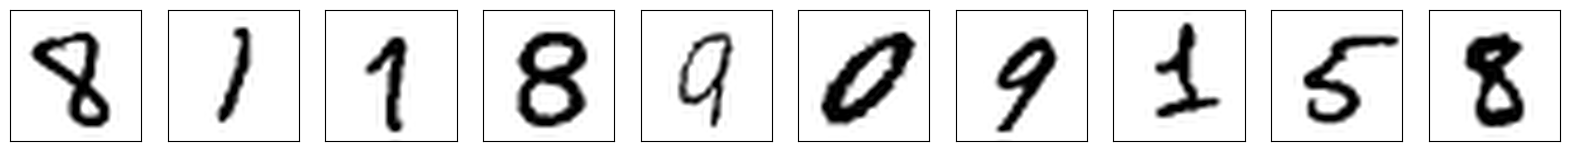

<br>**Reconstructed :**

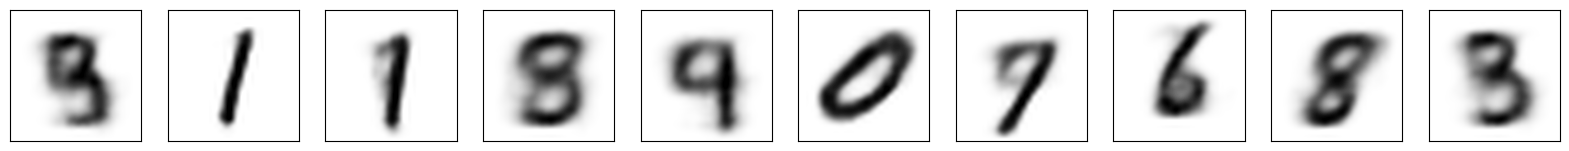

In [6]:
# ---- Select few images

x_show = fidle.utils.pick_dataset(x_data, n=10)

# ---- Get latent points and reconstructed images

z_mean, z_var, z  = vae.encoder.predict(x_show, verbose=0)
x_reconst         = vae.decoder.predict(z,      verbose=0)

latent_dim        = z.shape[1]

# ---- Show it

labels=[ str(np.round(z[i],1)) for i in range(10) ]
fidle.utils.subtitle('Originals :')
fidle.scrawler.images(x_show,    None, indices='all', columns=10, x_size=2,y_size=2, save_as='01-original')
fidle.utils.subtitle('Reconstructed :')
fidle.scrawler.images(x_reconst, None, indices='all', columns=10, x_size=2,y_size=2, save_as='02-reconstruct')


## Step 5 - Visualizing the latent space

In [7]:
n_show = min( 20000, len(x_data) )

# ---- Select images

x_show, y_show = fidle.utils.pick_dataset(x_data,y_data, n=n_show)

# ---- Get latent points

z_mean, z_var, z = vae.encoder.predict(x_show, verbose=0)

### 5.1 - Classic 2d visualisaton

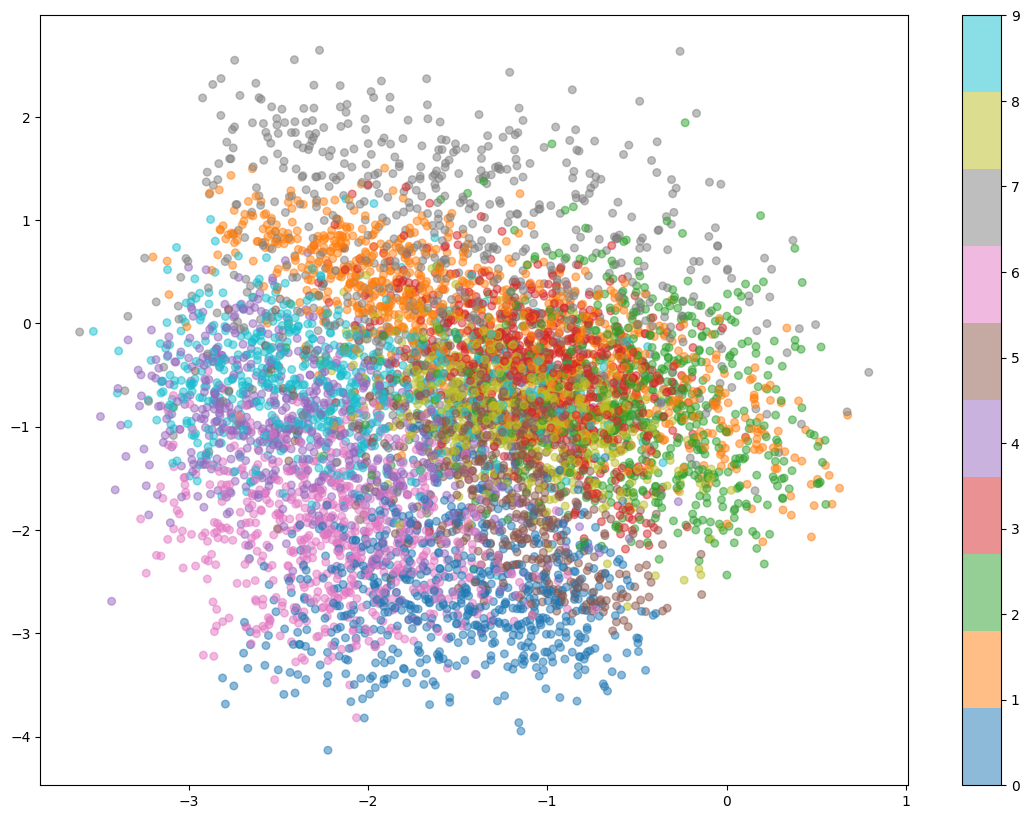

In [21]:
fig = plt.figure(figsize=(14, 10))
plt.scatter(z[:, 2] , z[:, 4], c=y_show, cmap= 'tab10', alpha=0.5, s=30)
plt.colorbar()
fidle.scrawler.save_fig('03-Latent-space')
plt.show()

### 5.2 - Simplex visualisaton

The latent space can be visualized as a **simplex**, which provides a convenient geometric interpretation of low-dimensional representations.

##### Mathematical definition
A **simplex** is the generalization of:
- a segment in dimension 1,
- a triangle in dimension 2,
- a tetrahedron in dimension 3.

More formally, the **\(n\)-simplex** is the convex hull of \(n+1\) affinely independent points:
$$
\Delta_n = \left\{ x \in \mathbb{R}^{n+1} \; : \; x_i \geq 0,\; \sum_{i=1}^{n+1} x_i = 1 \right\}.
$$

This means that each point in the simplex is a convex combination of its vertices.

##### Why use a simplex for the latent space?
When latent representations are constrained to be nonnegative and to sum to one, they naturally lie in a simplex.  
This makes interpretation easier: each coordinate can be seen as a proportion or a contribution to the representation.

##### Visualization tool
The visualization is performed with **`barviz`**, a library built on top of **`plotly`**, which makes it possible to display simplex-based latent representations in an interactive way.

In [8]:
if latent_dim<4:

    print('Sorry, This part can only work if the latent space is greater than 3')

else:

    # ---- Softmax rescale
    #
    zs = np.exp(z)/np.sum(np.exp(z),axis=1,keepdims=True)
    # zc  = zs * 1/np.max(zs)

    # ---- Create collection
    #
    c = Collection(zs, colors=y_show, labels=y_show)
    c.attrs.markers_colormap     = {'colorscale':'Rainbow','cmin':0,'cmax':latent_dim}
    c.attrs.markers_size         = 5
    c.attrs.markers_border_width = 0
    c.attrs.markers_opacity      = 0.8

    s = Simplex.build(latent_dim)
    s.attrs.width  = 1000
    s.attrs.height = 1000
    s.plot(c)

Sorry, This part can only work if the latent space is greater than 3


## Step 6 - Generate from latent space (latent_dim==2)

In [12]:
if latent_dim>2:

    print('Sorry, This part can only work if the latent space is of dimension 2')

else:

    grid_size   = 14
    grid_scale  = 1.

    # ---- Draw a ppf grid

    grid=[]
    for y in scipy.stats.norm.ppf(np.linspace(0.99, 0.01, grid_size),scale=grid_scale):
        for x in scipy.stats.norm.ppf(np.linspace(0.01, 0.99, grid_size),scale=grid_scale):
            grid.append( (x,y) )
    grid=np.array(grid)

    # ---- Draw latentspoints and grid

    fig = plt.figure(figsize=(12, 10))
    plt.scatter(z[:, 0] , z[:, 1], c=y_show, cmap= 'tab10', alpha=0.5, s=20)
    plt.scatter(grid[:, 0] , grid[:, 1], c = 'black', s=60, linewidth=2, marker='+', alpha=1)
    fidle.scrawler.save_fig('04-Latent-grid')
    plt.show()

    # ---- Plot grid corresponding images

    x_reconst = vae.decoder.predict([grid])
    fidle.scrawler.images(x_reconst, indices='all', columns=grid_size, x_size=0.5,y_size=0.5, y_padding=0,spines_alpha=0.1, save_as='05-Latent-morphing')



NameError: name 'scipy' is not defined

In [2]:
pip install cdsapi

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -------- ------------------------------- 1/5 [tqdm]
   -----

In [4]:
import cdsapi

dataset = "sis-extreme-indices-cmip6"
request = {
    "variable": ["maximum_5_day_precipitation"],
    "product_type": ["base_independent"],
    "model": ["cnrm_cm6_1"],
    "ensemble_member": ["r1i1p1f2"],
    "experiment": ["historical"],
    "temporal_aggregation": ["monthly"],
    "period": ["185001_201412"],
    "version": ["2_0"]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


Exception: Missing/incomplete configuration file: C:\Users\admin/.cdsapirc